In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [25]:
df = pd.read_csv("heart_disease_risk_dataset_earlymed.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [26]:
df = df.dropna()

print("After removing missing values:", df.shape)

After removing missing values: (70000, 19)


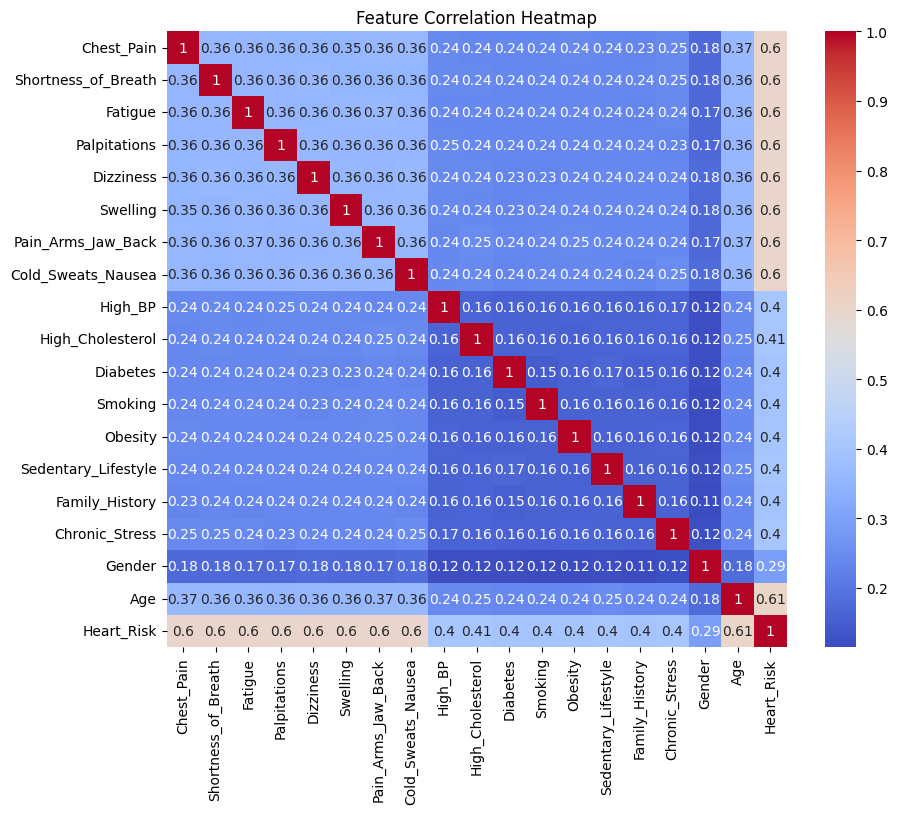

In [27]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
target_column = "Heart_Risk"

X = df.drop(columns=[target_column])
y = df[target_column]

In [29]:
X = X + np.random.normal(0, 0.2, X.shape)

training_columns = X.columns.tolist()

In [30]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (42000, 18)
Validation: (14000, 18)
Test: (14000, 18)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [32]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [33]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))

test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))


===== RESULTS =====
Training Accuracy   : 0.9921
Validation Accuracy : 0.9881
Test Accuracy       : 0.9879
Precision           : 0.9873
Recall              : 0.9884
F1 Score            : 0.9879

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [39]:
# SAVE MODEL, SCALER, AND COLUMNS

joblib.dump(model, "random_forest_heart_model.pkl")
joblib.dump(scaler, "scaler_heart.pkl")
joblib.dump(training_columns, "columns_heart.pkl")

print("\nModel, scaler, and columns saved successfully.")


Model, scaler, and columns saved successfully.


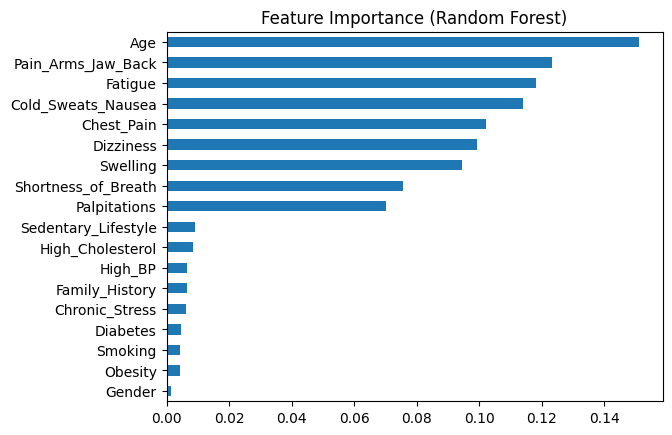

In [40]:
importance = model.feature_importances_

features = pd.Series(importance, index=training_columns)

features.sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.show()

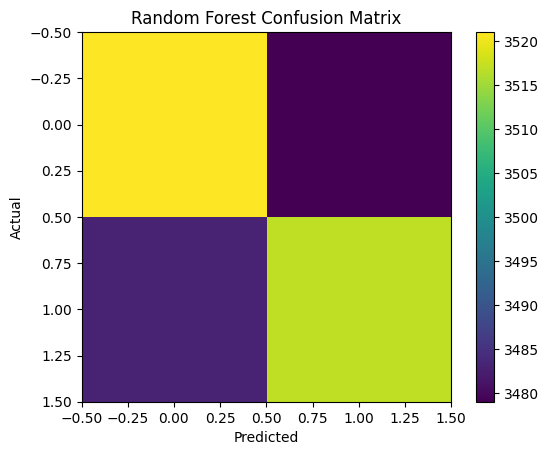

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [43]:
#manual testing

manual_input = {
    'Chest_Pain': 1,
    'Shortness_of_Breath': 1,
    'Fatigue': 0,
    'Palpitations': 0,
    'Dizziness': 0,
    'Swelling': 0,
    'Pain_Arms_Jaw_Back': 1,
    'Cold_Sweats_Nausea': 0,
    'High_BP': 1,
    'High_Cholesterol': 1,
    'Diabetes': 0,
    'Smoking': 1,
    'Obesity': 0,
    'Sedentary_Lifestyle': 1,
    'Family_History': 1,
    'Chronic_Stress': 1,
    'Gender': 1,
    'Age': 55
}

# Load the saved model, scaler, and columns
model = joblib.load("random_forest_heart_model.pkl")
scaler = joblib.load("scaler_heart.pkl")
training_columns = joblib.load("columns_heart.pkl")

# Convert input to DataFrame
input_df = pd.DataFrame([manual_input])

# Ensure column order matches training
input_df = input_df[training_columns]

# Scale the input
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled)[0]
probability = model.predict_proba(input_scaled)[0][1]

# Display results
print("\n===== MANUAL TEST =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST =====
Prediction: No Heart Disease
Probability: 0.3230
